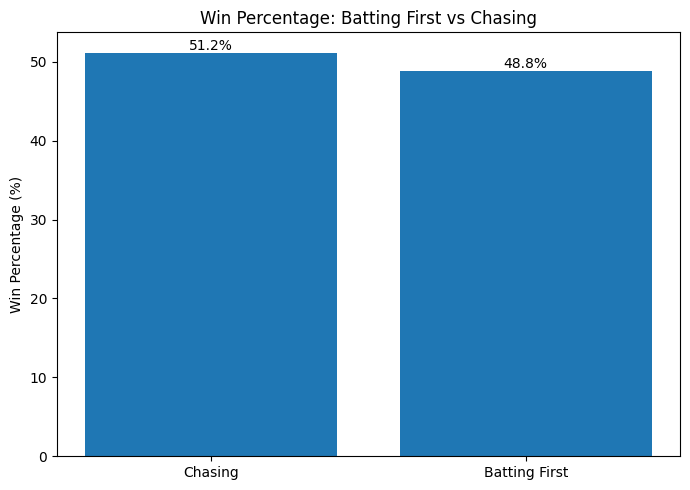

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_world_cup_data.csv")

# Determine if the team that batted first also won the match
# This assumes 'winner' and 'batting_first' columns are available in df,
# where 'batting_first' contains the name of the team that batted first.
batting_first_won = (df['winner'] == df['batting_first'])

# Calculate the percentage of matches won by batting first vs. chasing
# This will give a Series with index True (batting first won) / False (chasing team won)
win_percentages = batting_first_won.value_counts(normalize=True) * 100

# Get the percentage for chasing wins (False) and batting first wins (True)
chasing_wins_pct = win_percentages.get(False, 0) # Use .get() to handle cases where one category might not exist
batting_first_wins_pct = win_percentages.get(True, 0)

plot_data = [chasing_wins_pct, batting_first_wins_pct]
labels = ['Chasing', 'Batting First']

plt.figure(figsize=(7,5))
bars = plt.bar(labels, plot_data)

plt.title("Win Percentage: Batting First vs Chasing")
plt.ylabel("Win Percentage (%)")

# Data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.1f}%",
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

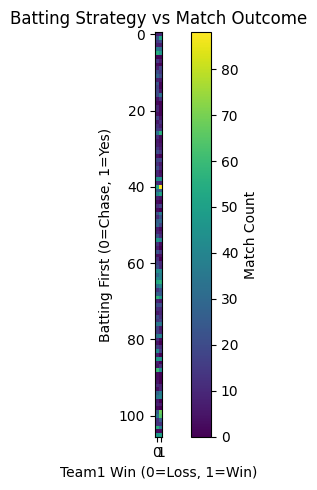

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_world_cup_data.csv")

strategy_result = pd.crosstab(df['batting_first'],
                              df['winner'] == df['team1'])

plt.figure(figsize=(6,5))
plt.imshow(strategy_result)

plt.title("Batting Strategy vs Match Outcome")
plt.xlabel("Team1 Win (0=Loss, 1=Win)")
plt.ylabel("Batting First (0=Chase, 1=Yes)")
plt.colorbar(label="Match Count")

plt.tight_layout()
plt.show()


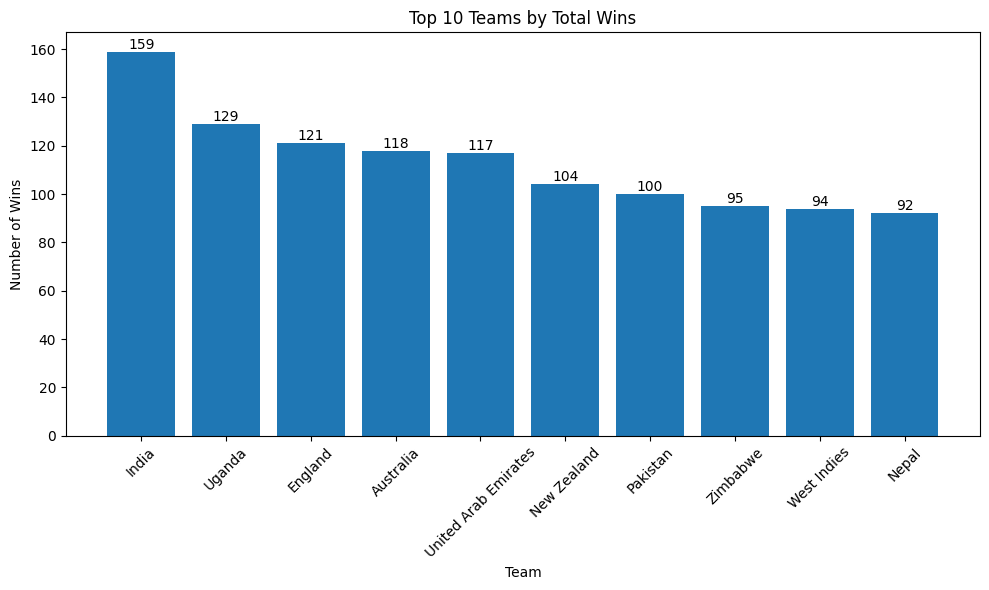

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_world_cup_data.csv")

top_teams = df['winner'].value_counts().head(10)

plt.figure(figsize=(10,6))
bars = plt.bar(top_teams.index, top_teams.values)

plt.title("Top 10 Teams by Total Wins")
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45)

# Data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(int(height)), ha='center', va='bottom')

plt.tight_layout()
plt.show()

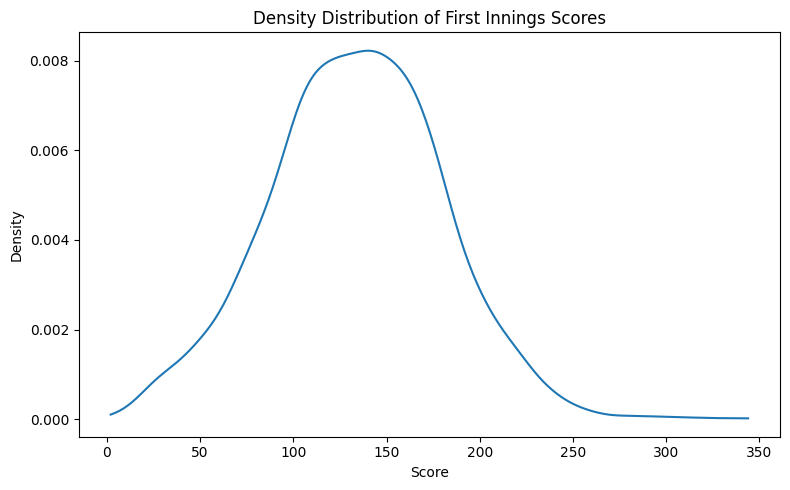

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

df = pd.read_csv("cleaned_world_cup_data.csv")

scores = df['first_innings_score'].dropna()

density = gaussian_kde(scores)
xs = np.linspace(scores.min(), scores.max(), 300)

plt.figure(figsize=(8,5))
plt.plot(xs, density(xs))

plt.title("Density Distribution of First Innings Scores")
plt.xlabel("Score")
plt.ylabel("Density")

plt.tight_layout()
plt.show()



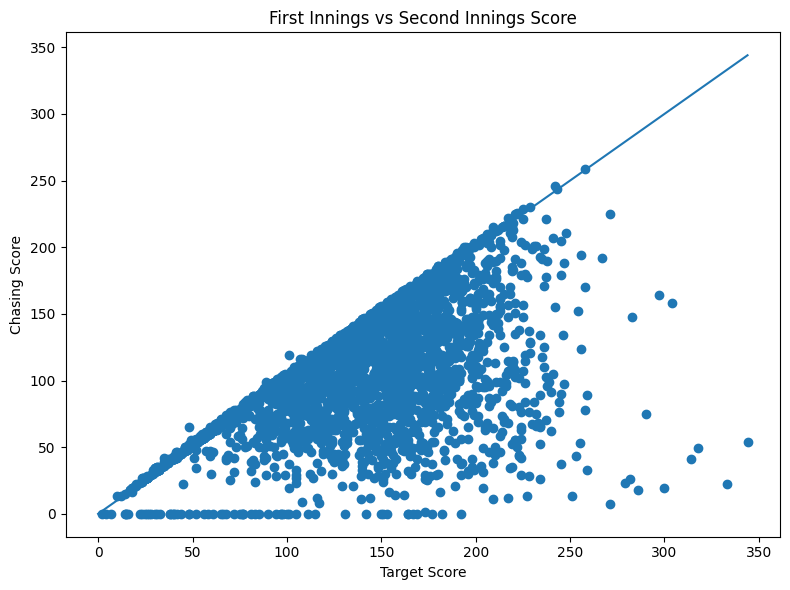

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_world_cup_data.csv")

plt.figure(figsize=(8,6))
plt.scatter(df['first_innings_score'], df['second_innings_score'])

max_score = max(df['first_innings_score'].max(),
                df['second_innings_score'].max())

plt.plot([0, max_score], [0, max_score])

plt.title("First Innings vs Second Innings Score")
plt.xlabel("Target Score")
plt.ylabel("Chasing Score")

plt.tight_layout()
plt.show()


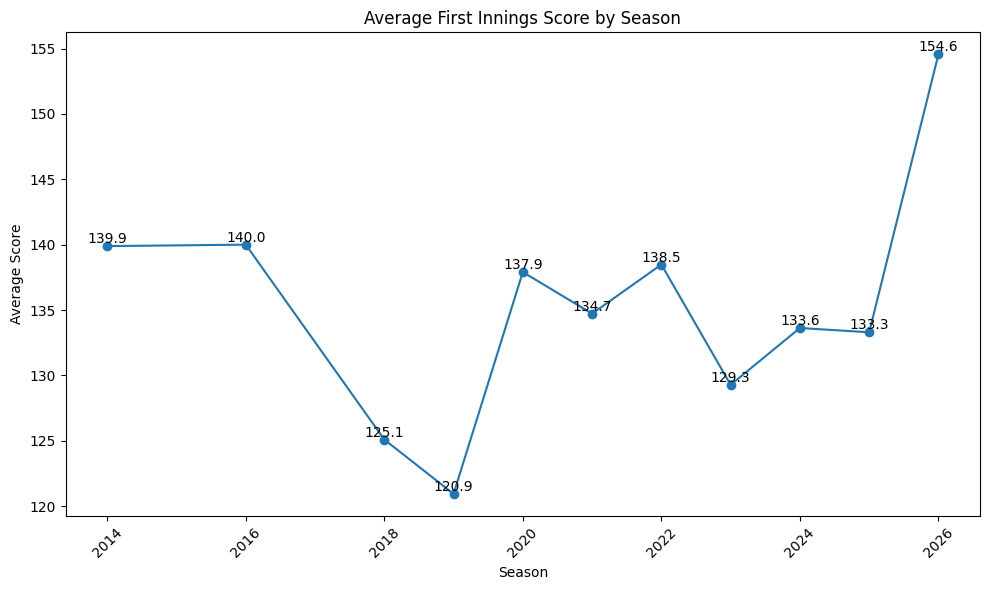

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_world_cup_data.csv")

season_avg = df.groupby('season')['first_innings_score'].mean()

plt.figure(figsize=(10,6))
plt.plot(season_avg.index, season_avg.values, marker='o')

plt.title("Average First Innings Score by Season")
plt.xlabel("Season")
plt.ylabel("Average Score")
plt.xticks(rotation=45)

for i, value in enumerate(season_avg.values):
    plt.text(season_avg.index[i], value,
             f"{value:.1f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


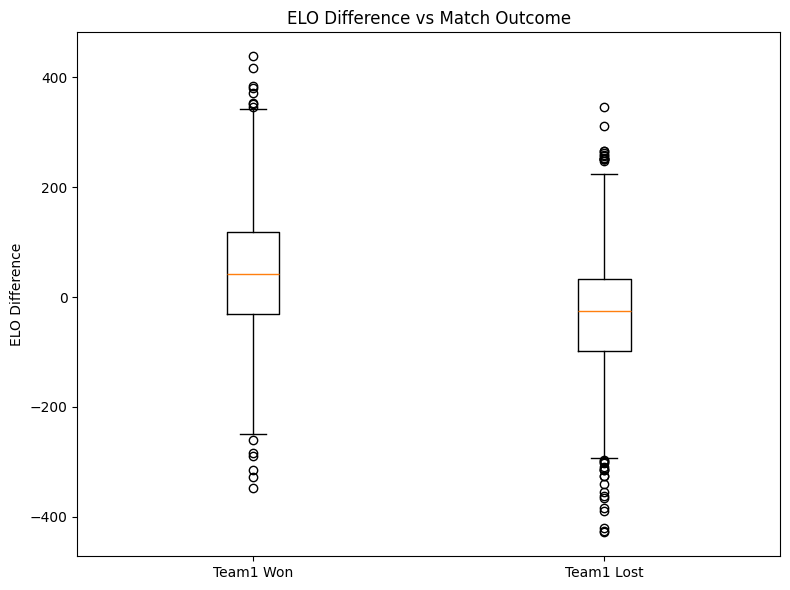

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_world_cup_data.csv")

df['team1_win'] = (df['winner'] == df['team1'])

data = [df[df['team1_win'] == True]['elo_diff'],
        df[df['team1_win'] == False]['elo_diff']]

plt.figure(figsize=(8,6))
plt.boxplot(data)

plt.xticks([1,2], ['Team1 Won', 'Team1 Lost'])
plt.title("ELO Difference vs Match Outcome")
plt.ylabel("ELO Difference")

plt.tight_layout()
plt.show()


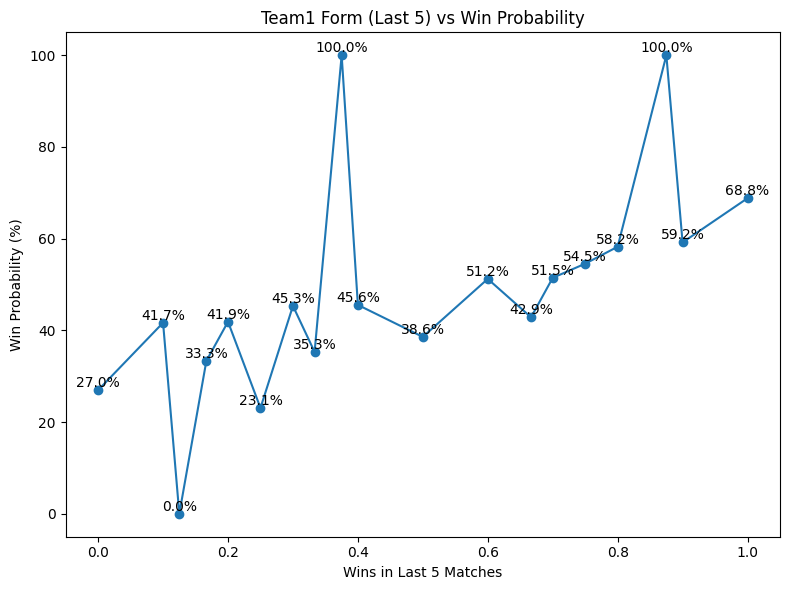

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_world_cup_data.csv")

df['team1_win'] = (df['winner'] == df['team1']).astype(int)

form_win = df.groupby('team1_form_5')['team1_win'].mean() * 100

plt.figure(figsize=(8,6))
plt.plot(form_win.index, form_win.values, marker='o')

plt.title("Team1 Form (Last 5) vs Win Probability")
plt.xlabel("Wins in Last 5 Matches")
plt.ylabel("Win Probability (%)")

for i, value in enumerate(form_win.values):
    plt.text(form_win.index[i], value,
             f"{value:.1f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()


/tmp/ipython-input-244676880.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h2h_analysis = df.groupby('h2h_bin')['team1_win'].mean() * 100


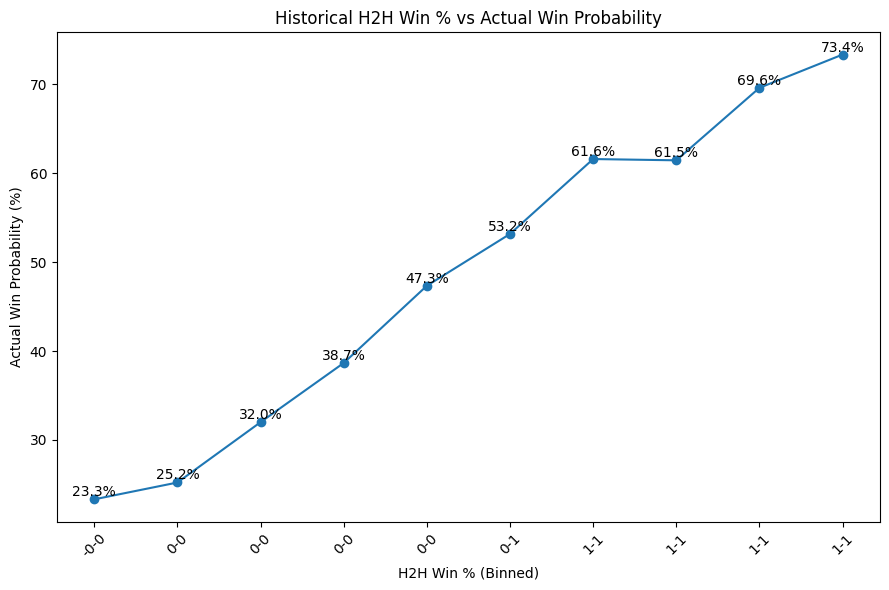

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_world_cup_data.csv")

# Create win indicator
df['team1_win'] = (df['winner'] == df['team1']).astype(int)

# Create bins for H2H %
df['h2h_bin'] = pd.cut(df['h2h_win_pct'], bins=10)

# Calculate win probability in each bin
h2h_analysis = df.groupby('h2h_bin')['team1_win'].mean() * 100

# Plot
plt.figure(figsize=(9,6))
plt.plot(range(len(h2h_analysis)), h2h_analysis.values, marker='o')

plt.title("Historical H2H Win % vs Actual Win Probability")
plt.xlabel("H2H Win % (Binned)")
plt.ylabel("Actual Win Probability (%)")

plt.xticks(range(len(h2h_analysis)),
           [f"{interval.left:.0f}-{interval.right:.0f}" for interval in h2h_analysis.index],
           rotation=45)

# Data labels
for i, value in enumerate(h2h_analysis.values):
    plt.text(i, value, f"{value:.1f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()



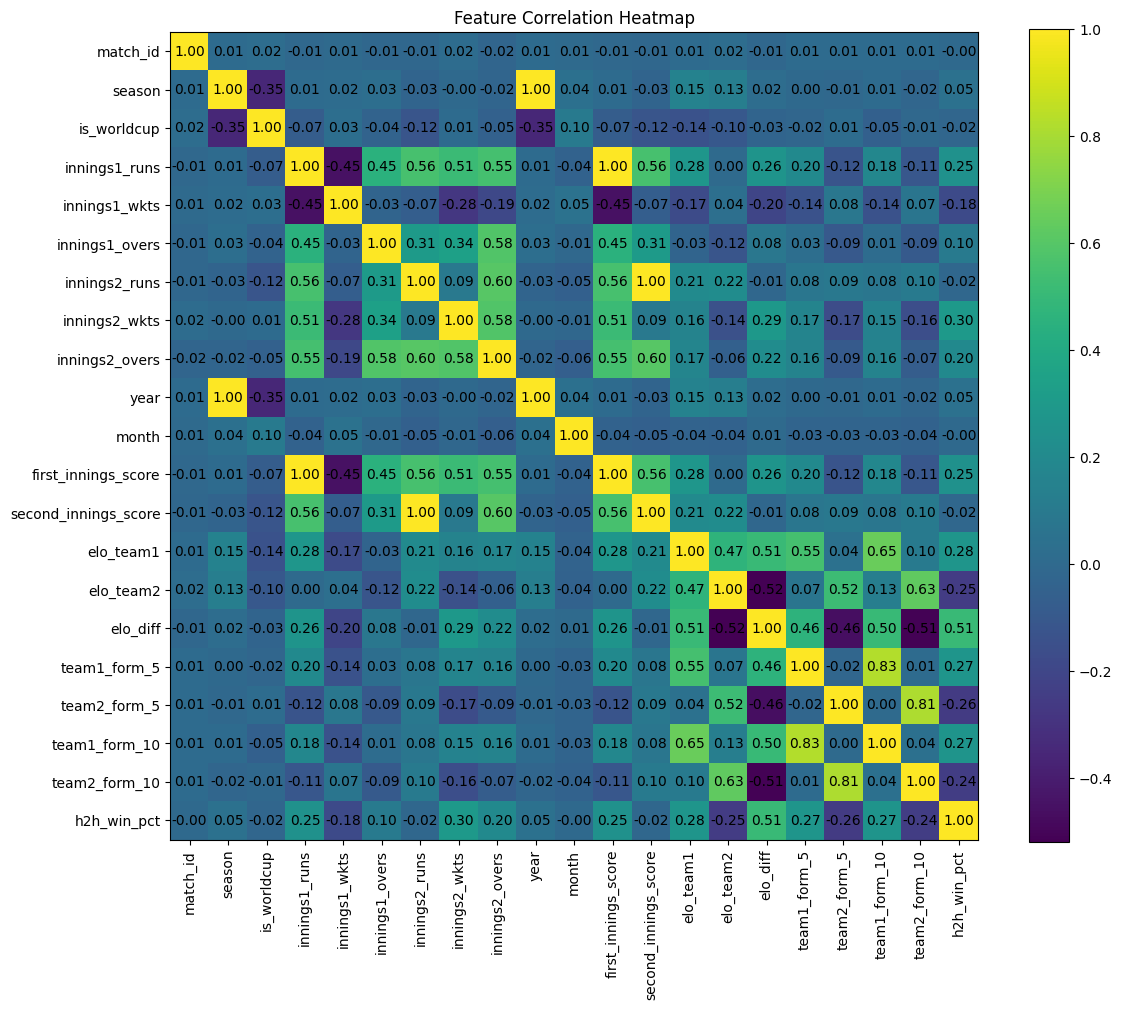

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("cleaned_world_cup_data.csv")

numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(12,10))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation Heatmap")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center')

plt.tight_layout()
plt.show()